Fig 1C

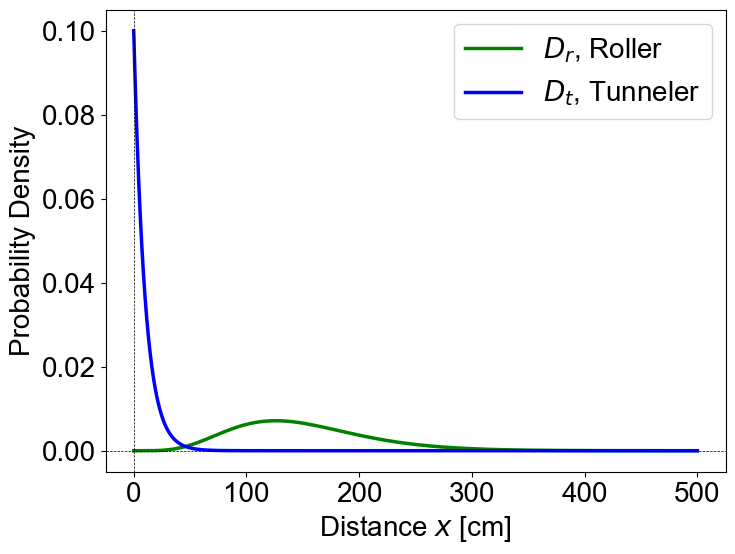

In [68]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 20


# Before introduction　1species


K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

#Parameter Set

s = 0.5 #Propotion of second dung beetle
n_r = (1-s)*K
n_t = s*K

n_r_af = n_r
n_t_af = n_t

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

a = 1 #attack rate
psai_p = 1 #predator遭遇確率
h = 1 #handling time

z= 1
c= 0.25


#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


plt.figure(figsize=(8, 6))

plt.plot(x_l, D_rol, label="$D_{r}$, Roller", color='green',linewidth=2.5)
plt.plot(x_l, D_tun, label="$D_{t}$, Tunneler", color='blue',linewidth=2.5)

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  

# plt.title("Shapes of Distribution")
plt.xlabel("Distance $x$ [cm]")
plt.ylabel("Probability Density")
plt.legend()
plt.show()









Fig2a Calcuration


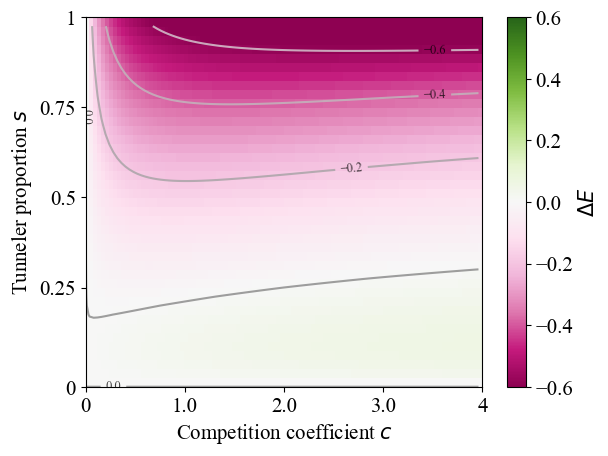

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Times New Roman' #Setting font
plt.rcParams["font.size"] = 15

#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

I  = 100
z = 1



#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


# Seedling establishment probability
def S(x):
    return 1 / (1+(c*(x**z)))



# Parametr range of s and p.
s_max = 1
s_bunkatu = 41
s_l = np.linspace(0, s_max, s_bunkatu)

c_max = 4
c_bunkatu = 100
c = np.linspace(0, c_max, c_bunkatu)


#Simulate Roller only community
N1y_bf = I*n_r_bf

NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
NDr_single_bf = [T*D for D in D_rol]

E_r_bf = [i* S(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
E_sum_bf = (sum(E_r_bf))*dd



E_Delta_l = []

for s in s_l:

    n_r = (1-s)*K
    n_t = s*K

    n_r_af = n_r
    n_t_af = n_t



    ##Cal Seedling Roller + Tunneler 
    # print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

    Nr  = I*Fr*n_r
    Nt  = I*Ft*n_t


    Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
    Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

    NDr_total = [Nr*D for D in D_rol] 
    NDt_total = [Nt*D for D in D_tun]

    NDr_single = [Nr_single*D for D in D_rol] 
    NDt_single = [Nt_single*D for D in D_tun]


    ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
    ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 


    E_rt = [i* S(j) for i, j in zip(ND_total, ND_single)]


    E_sum_rt = (sum(E_rt))*dd
    E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf

    E_Delta_l.append(E_Delta)



X = range(len(c)) 
Y =range(len(s_l))

plt.figure()
plt.pcolor(E_Delta_l, 
           cmap='PiYG',
vmin=-0.6,vmax=0.6,
# aspect='auto', interpolation='none', origin='lower'
)
# plt.title("Seed Seedling Difference")
plt.colorbar(label='$ΔE$')
cs = plt.contour(X, Y, E_Delta_l,
            levels = [-0.8, -0.6, -0.4,-0.2, 0, 0.2, 0.4, 0.6, 0.8], 
            cmap="binary",
            alpha=0.75)
plt.clabel(cs, fontsize=9, colors="black") 
plt.xlabel(f"Competition coefficient $c$")
plt.ylabel("Tunneler proportion $s$")


plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75,  1]) #s

plt.show()

Making Fig2a

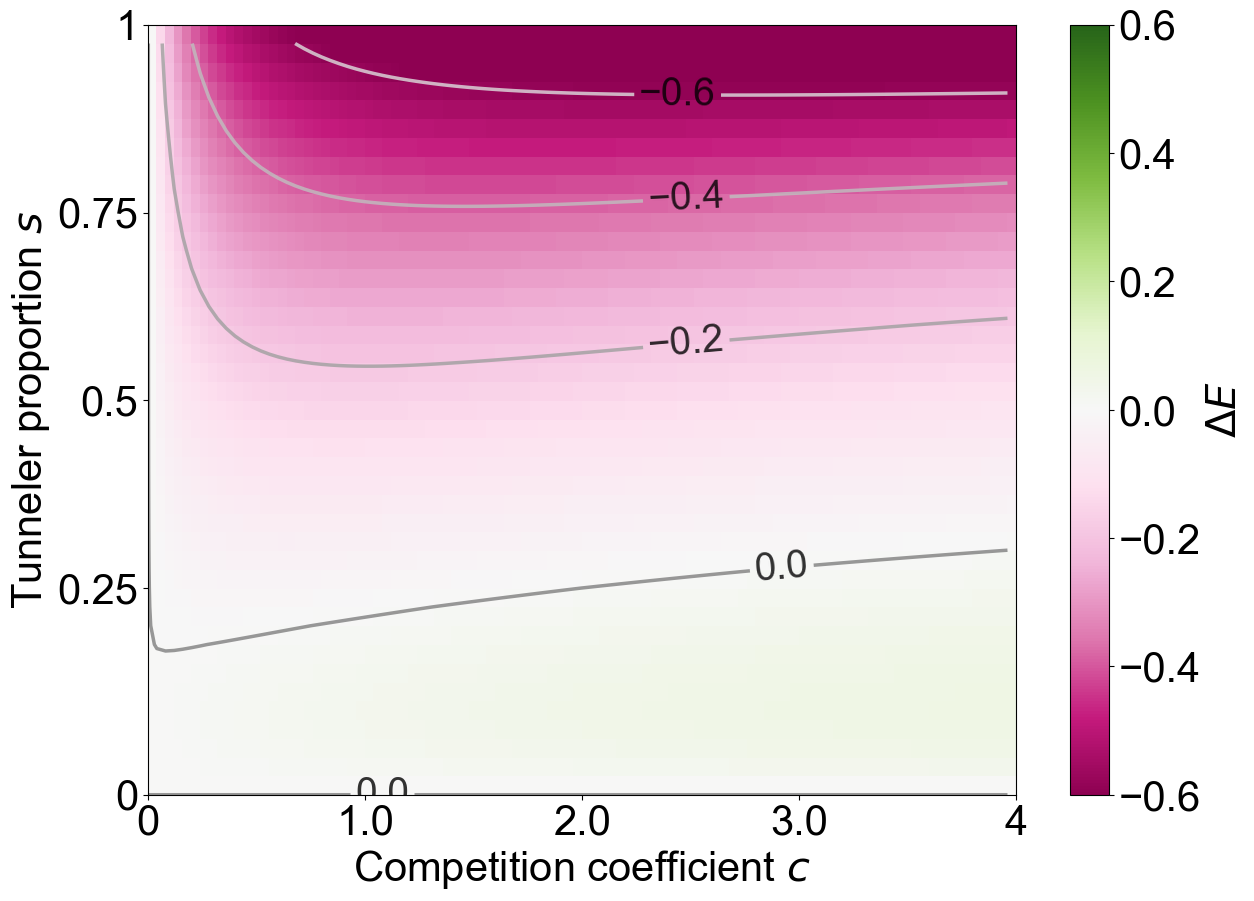

In [51]:

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 30

X = range(len(c)) 
Y =range(len(s_l))

plt.figure(figsize=(14, 10))
plt.pcolor(E_Delta_l, 
           cmap='PiYG',
vmin=-0.6,vmax=0.6,
# aspect='auto', interpolation='none', origin='lower'
)

plt.colorbar(label='$ \Delta E$')
cs = plt.contour(X, Y, E_Delta_l,
            levels = [-0.8, -0.6, -0.4,-0.2, 0, 0.2, 0.4, 0.6, 0.8], 
            cmap="binary",
            alpha=0.8,
            linewidths = 2.5)
plt.clabel(cs, fontsize=28, colors="black") 
plt.xlabel(f"Competition coefficient $c$")
plt.ylabel("Tunneler proportion $s$")


plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75,  1]) #s

plt.show()

Fig. S1

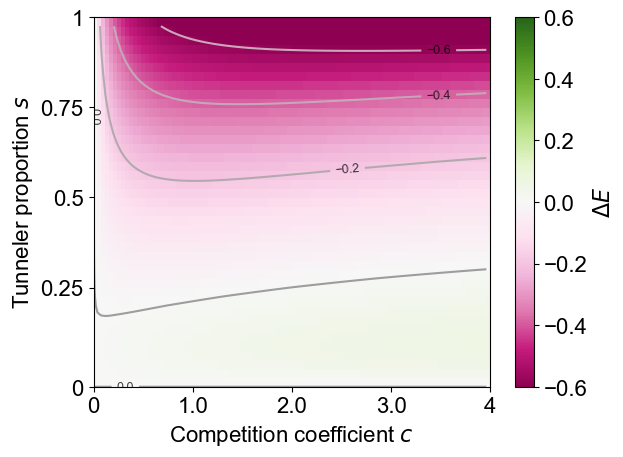

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 16

#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

I  = 100
z = 1



#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 1000
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


# Seedling establishment probability
def S(x):
    return 1 / (1+(c*(x**z)))



# Parametr range of s and p.
s_max = 1
s_bunkatu = 41
s_l = np.linspace(0, s_max, s_bunkatu)

c_max = 4
c_bunkatu = 100
c = np.linspace(0, c_max, c_bunkatu)


#Simulate Roller only community
N1y_bf = I*n_r_bf

NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
NDr_single_bf = [T*D for D in D_rol]

E_r_bf = [i* S(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
E_sum_bf = (sum(E_r_bf))*dd



E_Delta_l = []

for s in s_l:

    n_r = (1-s)*K
    n_t = s*K

    n_r_af = n_r
    n_t_af = n_t



    ##Cal Seedling Roller + Tunneler 
    # print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

    Nr  = I*Fr*n_r
    Nt  = I*Ft*n_t


    Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
    Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

    NDr_total = [Nr*D for D in D_rol] 
    NDt_total = [Nt*D for D in D_tun]

    NDr_single = [Nr_single*D for D in D_rol] 
    NDt_single = [Nt_single*D for D in D_tun]


    ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
    ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 


    E_rt = [i* S(j) for i, j in zip(ND_total, ND_single)]


    E_sum_rt = (sum(E_rt))*dd
    E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf

    E_Delta_l.append(E_Delta)



X = range(len(c)) 
Y =range(len(s_l))

plt.figure()
plt.pcolor(E_Delta_l, 
           cmap='PiYG',
vmin=-0.6,vmax=0.6,
# aspect='auto', interpolation='none', origin='lower'
)
# plt.title("Seed Seedling Difference")
plt.colorbar(label='$ΔE$')
cs = plt.contour(X, Y, E_Delta_l,
            levels = [-0.8, -0.6, -0.4,-0.2, 0, 0.2, 0.4, 0.6, 0.8], 
            cmap="binary",
            alpha=0.75)
plt.clabel(cs, fontsize=9, colors="black") 
plt.xlabel(f"Competition coefficient $c$")
plt.ylabel("Tunneler proportion $s$")


plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75,  1]) #s

plt.show()

Fig. 2b,c

Before Fr n_r=19.999999999999996
After Fr*n_r=19.999999999999996, G2n2=80.0


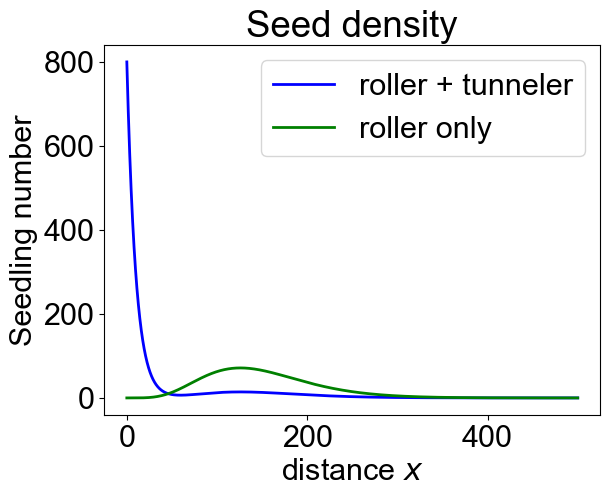

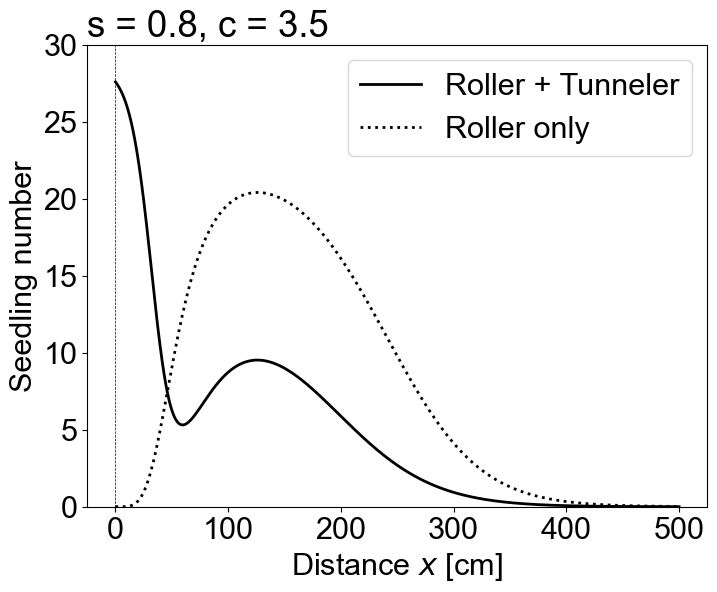

Before = 3990.623535111631, After = 2434.5454734177374


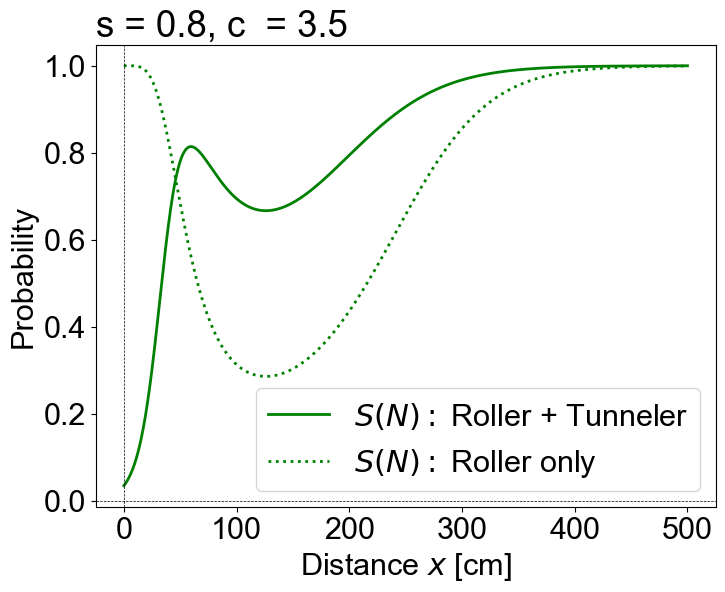

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 22


# Before introduction　1species


K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

#Parameter Set
s = 0.8 #Propotion of second dung beetle
n_r = (1-s)*K
n_t = s*K

n_r_af = n_r
n_t_af = n_t

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance


#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)



print(f"Before Fr n_r={Fr*n_r}")

I  = 100


#Simulate Roller only community
N1y_bf = I*n_r_bf
NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
NDr_single_bf = [T*D for D in D_rol]


def S(N):
    return 1 / (1+c*(N**(z)))

def S_net(N):
    return S(N)*P(N)

z= 1


c = 3.5


S_bf = [S(i) for i in NDr_single_bf]



E_r_bf = [i*S(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]

E_sum_bf = (sum(E_r_bf))*dd



##Cal Seedling Roller + Tunneler 
print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

Nr  = I*Fr*n_r
Nt  = I*Ft*n_t


Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

NDr_total = [Nr*D for D in D_rol] 
NDt_total = [Nt*D for D in D_tun]

ND_total = [Nr*D1+Nt*D2 for D1, D2 in zip(D_rol, D_tun)]

NDr_single = [Nr_single*D for D in D_rol] 
NDt_single = [Nt_single*D for D in D_tun]


plt.figure()
plt.title("Seed density")  
plt.xlabel("distance $x$")  
plt.ylabel("Seedling number")  
# plt.grid(alpha=0.3)  
plt.plot(x_l, ND_total, label=f"roller + tunneler", color='blue', linewidth=2)
plt.plot(x_l, NDr_total_bf, label=f"roller only", color='green', linewidth=2)

plt.legend()
plt.show()


ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 
ND_diff = (np.array(ND_total) - np.array(NDr_total_bf))/ max(np.array(ND_total) - np.array(NDr_total_bf))



S_af = [S(i) for i in ND_single]

S_diff = np.array(S_af) -np.array(S_bf)


E_rt = [i* S(j) for i, j in zip(ND_total, ND_single)]

E_diff = (np.array(E_rt) - np.array(E_r_bf))
E_diff_ratio = (np.array(E_rt) - np.array(E_r_bf))/max((np.array(E_rt) - np.array(E_r_bf)))


plt.figure(figsize=(8, 6))
plt.title(f"s = {s}, c = {c}", loc="left")  
plt.xlabel("Distance $x$ [cm]")  
plt.ylabel("Seedling number")  
plt.plot(x_l, E_rt, label=f"Roller + Tunneler", color='black', linewidth=2)
plt.plot(x_l, E_r_bf, label=f"Roller only", color='black', linestyle=":",linewidth=2)
plt.ylim(0, 30)

plt.legend()
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  
plt.savefig(f"Fig2b.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)
plt.show()




E_sum_rt = (sum(E_rt))*dd
print(f"Before = {E_sum_bf}, After = {E_sum_rt}") 



plt.figure(figsize=(8, 6))
plt.title(f"s = {s}, c  = {c}", loc="left")  
plt.xlabel("Distance $x$ [cm]")  
plt.ylabel("Probability")  

plt.plot(x_l, S_af, label=r"$S(N):$ Roller + Tunneler", color='green', linewidth=2)
plt.plot(x_l, S_bf, label=r"$S(N):$ Roller only", color='green', linestyle=":",linewidth=2)

plt.legend()
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  
plt.savefig(f"Fig2c.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)
plt.show()


Fig2d, e

Before Fr n_r=85.0
After Fr*n_r=85.0, G2n2=15.0


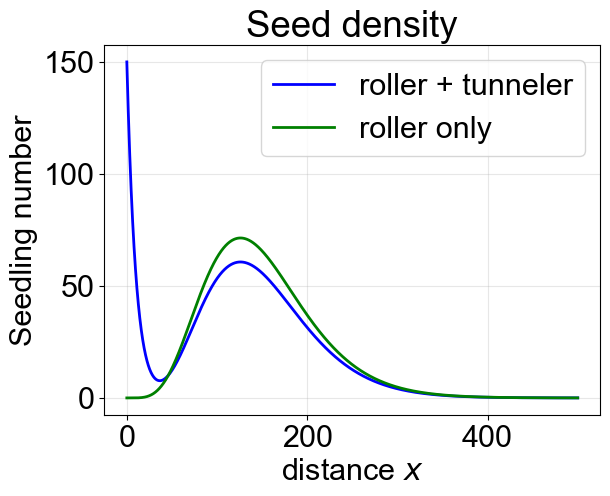

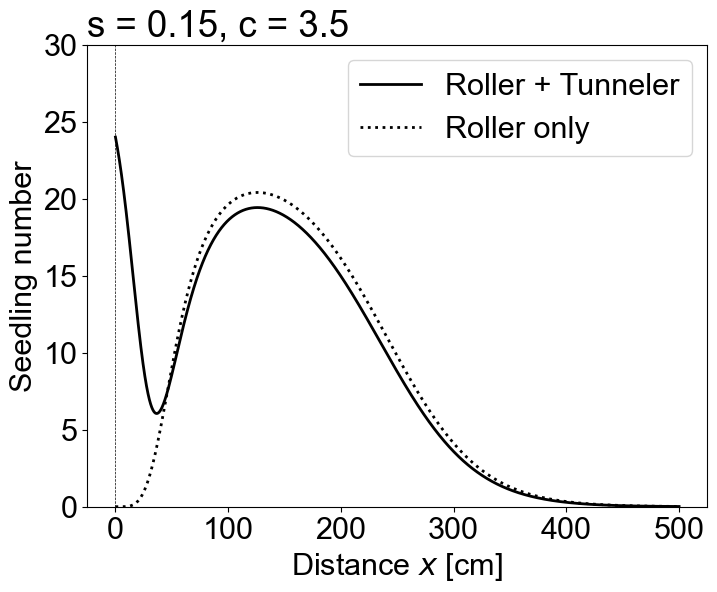

Before = 3990.623535111631, After = 4197.9598928337555


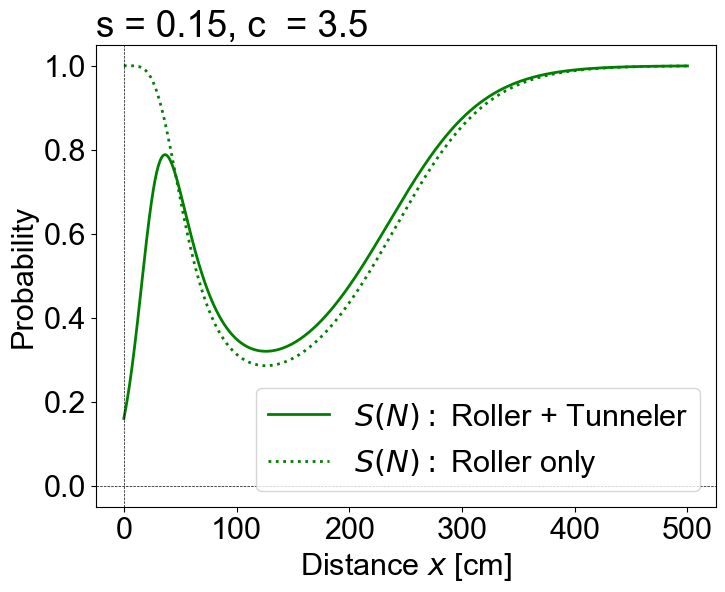

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 22


# Before introduction　1species


K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

#Parameter Set
s = 0.15 #Propotion of second dung beetle
n_r = (1-s)*K
n_t = s*K

n_r_af = n_r
n_t_af = n_t

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance


#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)



print(f"Before Fr n_r={Fr*n_r}")

I  = 100


#Simulate Roller only community
N1y_bf = I*n_r_bf
NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
NDr_single_bf = [T*D for D in D_rol]


def S(N):
    return 1 / (1+c*(N**(z)))

def S_net(N):
    return S(N)*P(N)

z= 1


c = 3.5


S_bf = [S(i) for i in NDr_single_bf]



E_r_bf = [i*S(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]

E_sum_bf = (sum(E_r_bf))*dd



##Cal Seedling Roller + Tunneler 
print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

Nr  = I*Fr*n_r
Nt  = I*Ft*n_t


Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

NDr_total = [Nr*D for D in D_rol] 
NDt_total = [Nt*D for D in D_tun]

ND_total = [Nr*D1+Nt*D2 for D1, D2 in zip(D_rol, D_tun)]

NDr_single = [Nr_single*D for D in D_rol] 
NDt_single = [Nt_single*D for D in D_tun]


plt.figure()
plt.title("Seed density")  
plt.xlabel("distance $x$")  
plt.ylabel("Seedling number")  
plt.grid(alpha=0.3)  
plt.plot(x_l, ND_total, label=f"roller + tunneler", color='blue', linewidth=2)
plt.plot(x_l, NDr_total_bf, label=f"roller only", color='green', linewidth=2)

plt.legend()
plt.show()


ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 
ND_diff = (np.array(ND_total) - np.array(NDr_total_bf))/ max(np.array(ND_total) - np.array(NDr_total_bf))



S_af = [S(i) for i in ND_single]

S_diff = np.array(S_af) -np.array(S_bf)


E_rt = [i* S(j) for i, j in zip(ND_total, ND_single)]

E_diff = (np.array(E_rt) - np.array(E_r_bf))
E_diff_ratio = (np.array(E_rt) - np.array(E_r_bf))/max((np.array(E_rt) - np.array(E_r_bf)))


plt.figure(figsize=(8, 6))
plt.title(f"s = {s}, c = {c}", loc="left")  
plt.xlabel("Distance $x$ [cm]")  
plt.ylabel("Seedling number")  
plt.plot(x_l, E_rt, label=f"Roller + Tunneler", color='black', linewidth=2)
plt.plot(x_l, E_r_bf, label=f"Roller only", color='black', linestyle=":",linewidth=2)
plt.ylim(0, 30)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  
plt.savefig(f"Fig2d.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)
plt.show()




E_sum_rt = (sum(E_rt))*dd
print(f"Before = {E_sum_bf}, After = {E_sum_rt}") 


plt.figure(figsize=(8, 6))
plt.title(f"s = {s}, c  = {c}", loc="left")  
plt.xlabel("Distance $x$ [cm]")  
plt.ylabel("Probability")  
# plt.plot(x_l, P_af, label=f"P_rt", color='red', linewidth=2)
# plt.plot(x_l, P_bf, label=f"P_t", color='red', linestyle=":",linewidth=2)

plt.plot(x_l, S_af, label=r"$S(N):$ Roller + Tunneler", color='green', linewidth=2)
plt.plot(x_l, S_bf, label=r"$S(N):$ Roller only", color='green', linestyle=":",linewidth=2)

plt.legend()
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  
plt.savefig(f"Fig2e.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)
plt.show()

Fig3 Calcuration

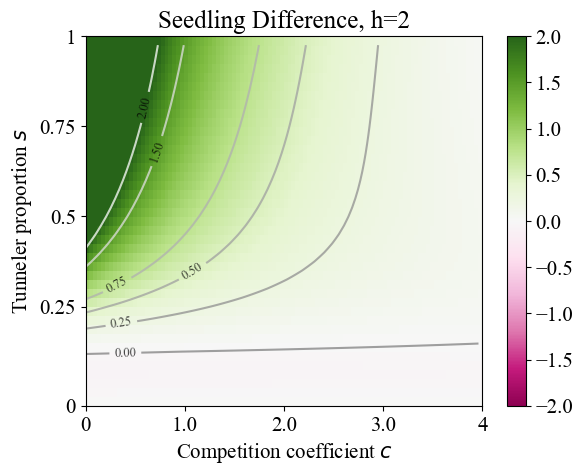

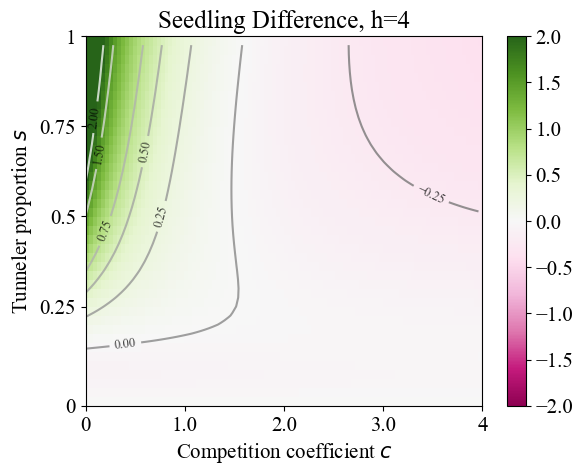

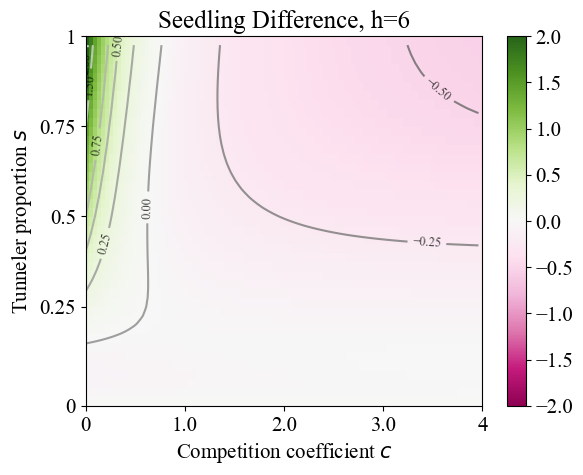

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.optimize import brentq


plt.rcParams['font.family'] = 'Times New Roman' #Setting font
plt.rcParams["font.size"] = 15


#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

z= 1
I = 100

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

#Parameter setting
a = 1     #Attack rate
h = 10   #Handling time
n_p = 0.4      #Density of predetors


T_fixed =  10  #TIme to germination T



#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 100
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


# Parametr range of s and p.
s_max = 1
s_bunkatu = 41
s_l = np.linspace(0, s_max, s_bunkatu)

c_max = 4
c_bunkatu = 100
c = np.linspace(0, c_max, c_bunkatu)




def S(N):
    return 1 / (1+c*(N**(z)))


def P(n0_current):

    # Define the Equation
    def solve_nt(NT, a, h, n_p, N0, Time):
        if NT <= 0:
            return -np.inf
        
        term1 = np.log(NT) - np.log(N0)
        term2 = a * h * (NT - N0)
        term3 = a * n_p * Time
        return term1 + term2 + term3

    
    # Search range
    lower_bound = 1e-25
    upper_bound = n0_current
    

    if n0_current < 1e-5:
        return 0


    else: 
        try:
            nt_solution = brentq(
                solve_nt, lower_bound, upper_bound, 
                args=(a, h, n_p, n0_current, T_fixed) )
            
            # S(T) = N(T) / N(0)
            survival_rate = nt_solution / n0_current
            P_N = survival_rate
            return P_N    

        except ValueError:
            
            P_N = np.nan
        
            return P_N

def S_net(N):
    return P(N)*S(N*P(N))




E_Delta_ll = []

h_l = [2, 4, 6]


for h in h_l:
        
    E_Delta_l = []


    #Simulate Roller only community
    N1y_bf = I*n_r_bf

    NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]

    NDr_single_bf = [I*D for D in D_rol]

    E_r_bf = [i* S_net(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
    E_sum_bf = (sum(E_r_bf))*dd


    for s in s_l:

        n_r = (1-s)*K
        n_t = s*K

        n_r_af = n_r
        n_t_af = n_t


        ##Cal Seedling Roller + Tunneler 
        # print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

        Nr  = I*Fr*n_r
        Nt  = I*Ft*n_t


        Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
        Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))


        NDr_total = Nr*D_rol
        NDt_total = Nt*D_tun

        NDr_single = Nr_single*D_rol 
        NDt_single = Nt_single* D_tun

        ND_total = NDr_total + NDt_total
        ND_single = NDr_single + NDt_single

        E_rt = [i* S_net(j) for i, j in zip(ND_total, ND_single)]


        E_sum_rt = (sum(E_rt))*dd
        E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf
        # E_Delta_l.append(E_Delta)
        E_Delta_l.append(E_Delta)

    E_Delta_ll.append(E_Delta_l)


    # Make figure
    X = range(len(c)) 
    Y =range(len(s_l))

    plt.figure()
    plt.pcolor(E_Delta_l, cmap='PiYG',
    vmin=-2,vmax=2,
    # aspect='auto', interpolation='none', origin='lower'
    )
    plt.title(f"Seedling Difference, h={h}")
    plt.colorbar()
    cs = plt.contour(X, Y, E_Delta_l,
                levels = [-2.0, -1.5, -0.75, -0.5,-0.25, 0, 0.25, 0.5, 0.75, 1.5, 2.0], 
                cmap="binary_r",
                alpha=0.75)
    plt.clabel(cs, fontsize=9, colors="black") 
    plt.xlabel(f"Competition coefficient $c$")
    plt.ylabel("Tunneler proportion $s$")


    plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
    plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75, 1]) #s

    plt.show()



/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/3187909515.py:22: UserWarning: The following kwargs were not used by contour: 'c', 'linewidth'
  cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/3187909515.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


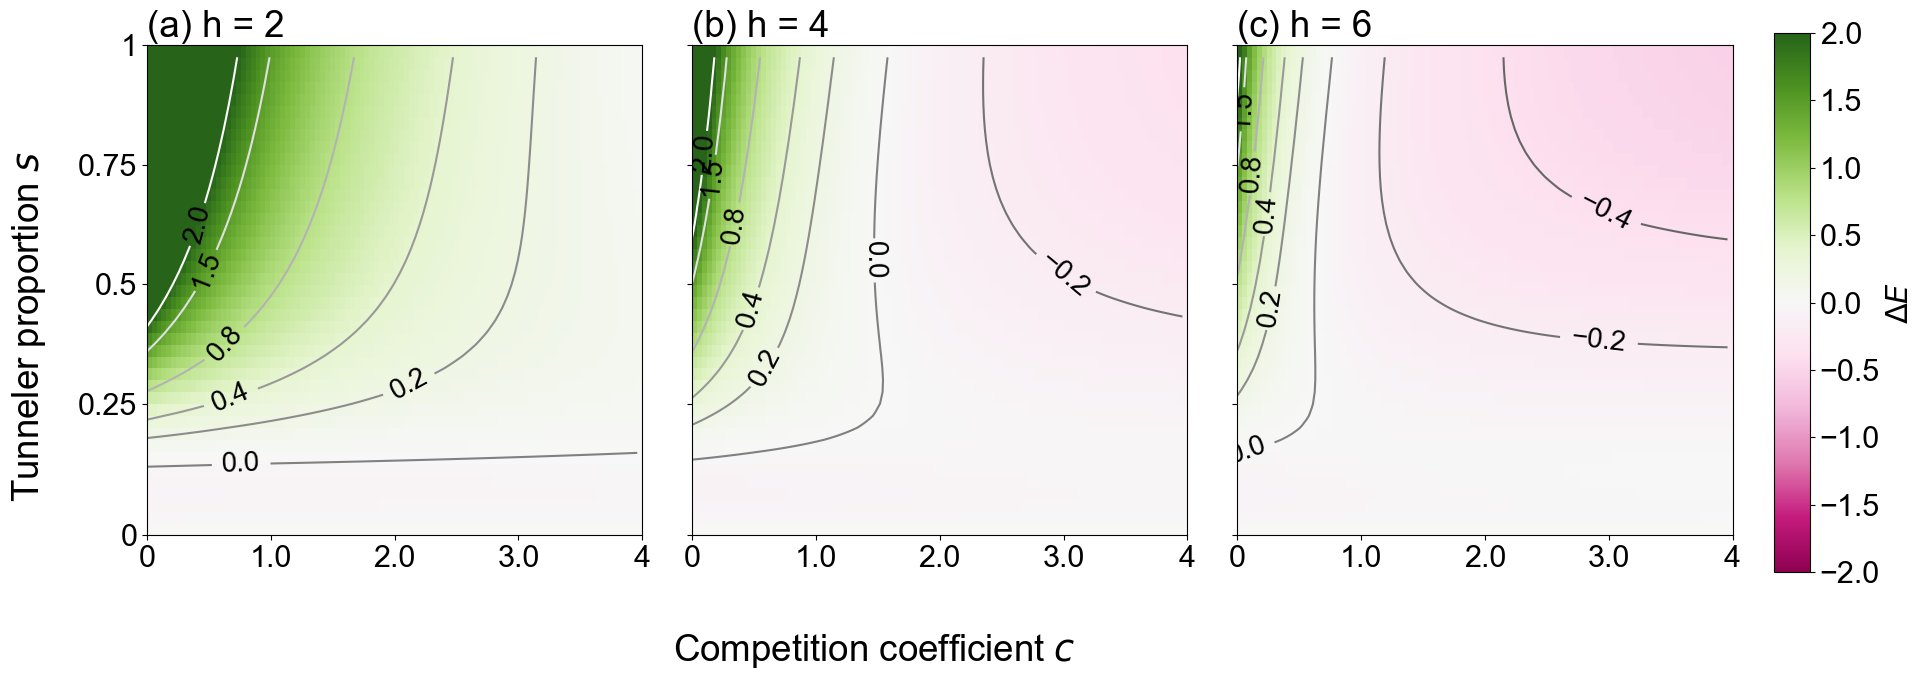

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 22


fig, axes = plt.subplots(1, 3, tight_layout=True, figsize=(18, 7), sharex=True, sharey="row")
ax1, ax2, ax3= axes[0], axes[1], axes[2] 
ax_l= [ax1, ax2, ax3]


title_l = [f"(a) h = {h_l[0]}", f"(b) h = {h_l[1]}", f"(c) h = {h_l[2]}"]

for j in range(3):


    ax_l[j].set_title(title_l[j], loc="left")
    im = ax_l[j].pcolor(E_Delta_ll[j], cmap='PiYG',
                    vmin=-2,vmax=2,
                    # aspect='auto', interpolation='none', origin='lower'
                    )

    cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
                    levels = [-2.0, -1.5, -0.8, -0.4,-0.2, 0, 0.2, 0.4, 0.8, 1.5, 2.0], 
                    cmap="binary_r",
                    c=0.8,
                    linewidth=3)



    plt.clabel(cs, fontsize=20, colors="black")  

plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75, 1]) #s


cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.77])

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('$\Delta E$') 

fig.supxlabel(f"Competition coefficient $c$")
fig.supylabel("Tunneler proportion $s$")


fig.tight_layout()

plt.savefig(f"Fig2abc.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)

plt.show()




FIg3 D, E

Before Fr n_r=100
s = 0.8
c= 0.5
After Fr*n_r=19.999999999999996, G2n2=80.0


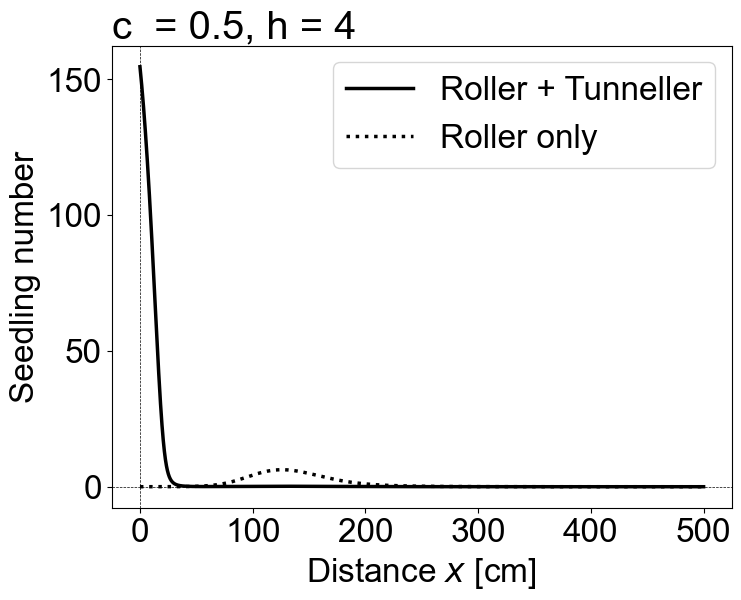

Before = 526.5726790091317, After = 1934.5372533273455


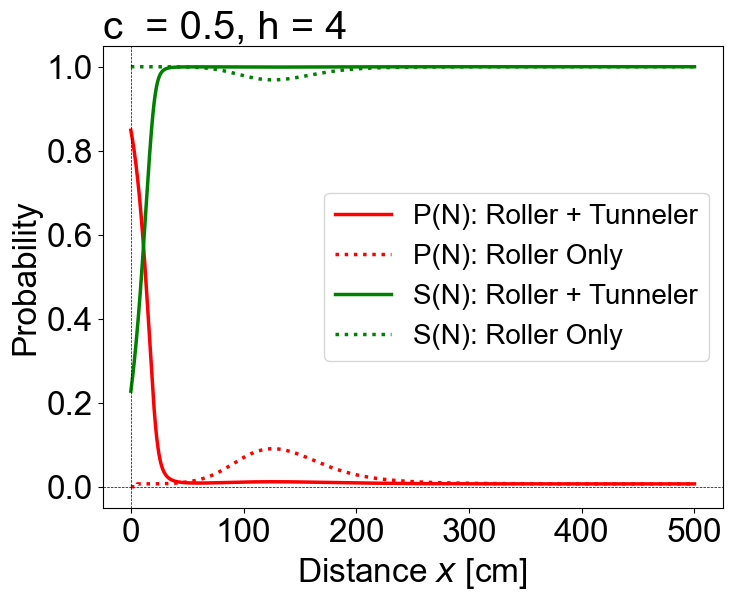

c= 3.5
After Fr*n_r=19.999999999999996, G2n2=80.0


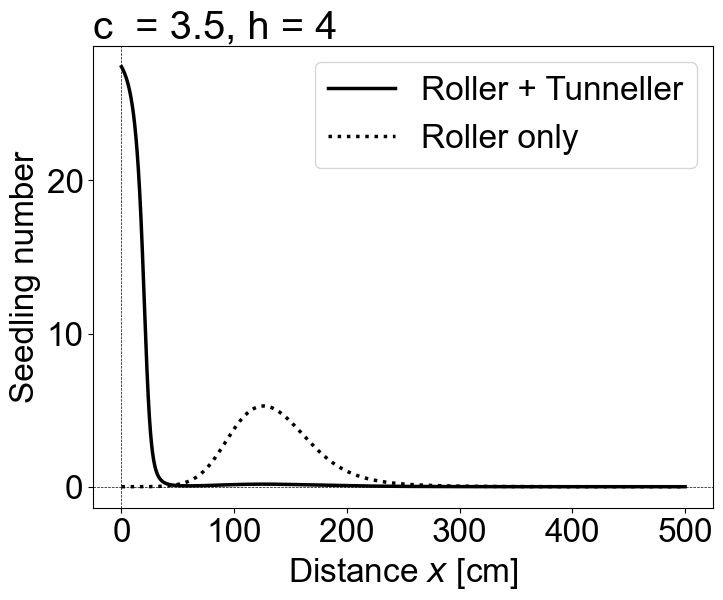

Before = 467.8294820594054, After = 543.5285297007448


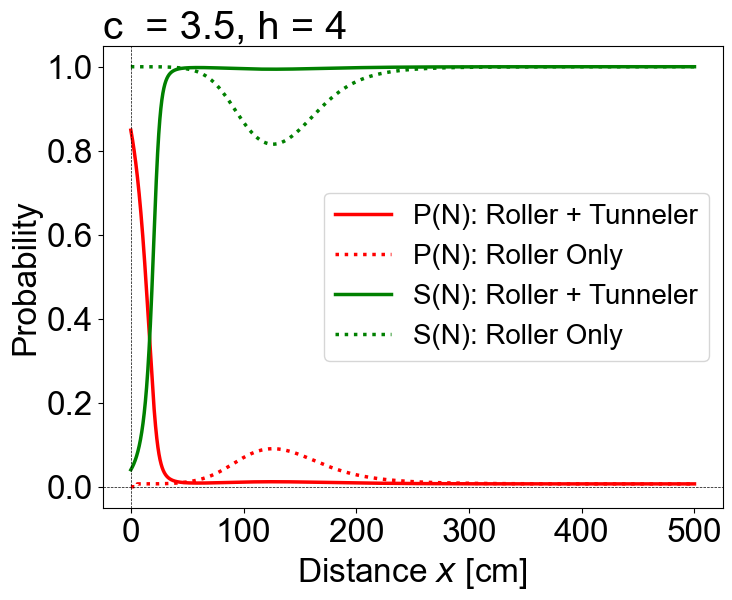

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.optimize import brentq


plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 24


# Before introduction　1species

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

z= 1

# alpha = 0.5

I = 100

T_fixed =  10  #TIme to germination T

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

a = 1 #attack rate
n_p = 0.5 #predator遭遇確率
h = 4 #handling time


T_fixed =  10  #TIme to germination T


#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)





print(f"Before Fr n_r={Fr*n_r}")



#Simulate Roller only community
N1y_bf = I*n_r_bf

NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
NDr_single_bf = [I*D for D in D_rol]


#Seedling establishment probability
def S(N):
    return 1 / (1+c*(N**(z)))


def P(n0_current):

    # Define the Equation
    def solve_nt(NT, a, h, n_p, N0, Time):
        if NT <= 0:
            return -np.inf
        
        term1 = np.log(NT) - np.log(N0)
        term2 = a * h * (NT - N0)
        term3 = a * n_p * Time
        return term1 + term2 + term3

    
    # Search range
    lower_bound = 1e-25
    upper_bound = n0_current
    

    if n0_current < 1e-5:
        return 0


    else: 
        try:
            nt_solution = brentq(
                solve_nt, lower_bound, upper_bound, 
                args=(a, h, n_p, n0_current, T_fixed) )
            
            # S(T) = N(T) / N(0)
            survival_rate = nt_solution / n0_current
            P_N = survival_rate
            return P_N    

        except ValueError:
            
            P_N = np.nan
        
            return P_N

def S_net(N):
    return P(N)*S(N*P(N))

def S_B(N):
    return S(N*P(N))


E_diff_ratio_l, ND_diff_l, Snet_diff_l, P_diff_l, comp_diff_l = [], [], [], [], []
param_l = []

c_l = [0.5, 3.5]


title_l = ["(d)", "(e)"]

s_l = [0.8]
for s in s_l:
    print("s =", s)

    for c in c_l:
        print("c=", c)


        comp_bf = [S(i) for i in NDr_single_bf]
        S_bf = [S_B(i) for i in NDr_single_bf]
        P_bf = [P(i) for i in NDr_single_bf]


        E_r_bf = [i* S_net(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]

        E_sum_bf = (sum(E_r_bf))*dd



        ##Cal Seedling Roller + Tunneler 

        n_r = (1-s)*K
        n_t = s*K


        print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

        Nr  = I*Fr*n_r
        Nt  = I*Ft*n_t


        Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
        Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

        NDr_total = [Nr*D for D in D_rol] 
        NDt_total = [Nt*D for D in D_tun]

        NDr_single = [Nr_single*D for D in D_rol] 
        NDt_single = [Nt_single*D for D in D_tun]


        ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
        ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 
        ND_diff = (np.array(ND_total) - np.array(NDr_total_bf))/ max(np.array(ND_total) - np.array(NDr_total_bf))


        comp_af = [S(i) for i in ND_single]
        S_af = [S_B(i) for i in ND_single]

        P_af = [P(i) for i in ND_single]

        comp_diff = (np.array(comp_af) -np.array(comp_bf)) / np.absolute(np.array(comp_af) -np.array(comp_bf)).max()
        Snet_diff = (np.array(S_af) -np.array(S_bf)) / np.absolute(np.array(S_af) -np.array(S_bf)).max()
        P_diff = (np.array(P_af) -np.array(P_bf)) / np.absolute(np.array(P_af) -np.array(P_bf)).max()



        E_rt = [i* S_net(j) for i, j in zip(ND_total, ND_single)]

        E_diff = (np.array(E_rt) - np.array(E_r_bf))
        E_diff_ratio = (np.array(E_rt) - np.array(E_r_bf))/max((np.array(E_rt) - np.array(E_r_bf)))


        plt.figure(figsize=(8, 6))
        plt.title(f"c  = {c}, h = {h}", loc="left")  
        plt.xlabel("Distance $x$ [cm]")  
        plt.ylabel("Seedling number")  
        plt.plot(x_l, E_rt, label=f"Roller + Tunneller", color='black', linewidth=2.5)
        plt.plot(x_l, E_r_bf, label=f"Roller only", color='black', linestyle=":",linewidth=2.5)

        plt.legend()
        plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
        plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  
        file_name_seedling = f"Seedling_number_c{c}_h{h}_s{s}"
        plt.savefig(f"{file_name_seedling}.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)
        plt.savefig(f"{file_name_seedling}.pdf", bbox_inches='tight')
        plt.show()



        E_sum_rt = (sum(E_rt))*dd
        print(f"Before = {E_sum_bf}, After = {E_sum_rt}") 


        plt.figure(figsize=(8, 6))
        plt.title(f"c  = {c}, h = {h}", loc="left")  
        plt.xlabel("Distance $x$ [cm]")  
        plt.ylabel("Probability")  
        plt.plot(x_l, P_af, label=f"P(N): Roller + Tunneler", color='red', linewidth=2.5)
        plt.plot(x_l, P_bf, label=f"P(N): Roller Only", color='red', linestyle=":",linewidth=2.5)

        plt.plot(x_l, S_af, label=f"S(N): Roller + Tunneler", color='green', linewidth=2.5)
        plt.plot(x_l, S_bf, label=f"S(N): Roller Only", color='green', linestyle=":",linewidth=2.5)

        plt.legend(fontsize="20")
        plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  
        plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  
        file_name_prob = f"Probability_c{c}_h{h}_s{s}"
        plt.savefig(f"{file_name_prob}.png", dpi=600, bbox_inches='tight') # 高解像度PNG (600 dpi)
        plt.savefig(f"{file_name_prob}.pdf", bbox_inches='tight')
        plt.show()


        E_diff_ratio_l.append(E_diff_ratio)
        ND_diff_l.append(ND_diff)
        Snet_diff_l.append(Snet_diff)
        P_diff_l.append(P_diff)
        comp_diff_l.append(comp_diff)
        param_l.append([s, c])



Fig. S2 Scenio A z=0.5, 2, 3

z= 0.5


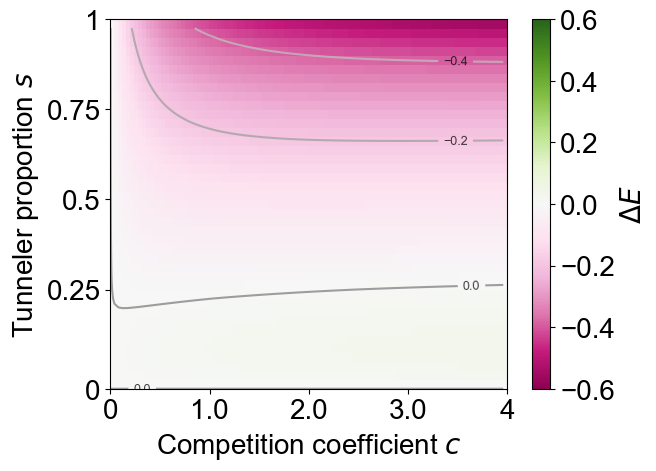

z= 2


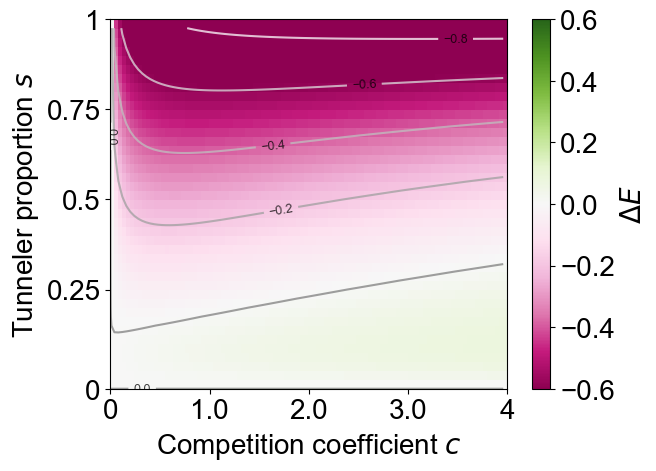

z= 3


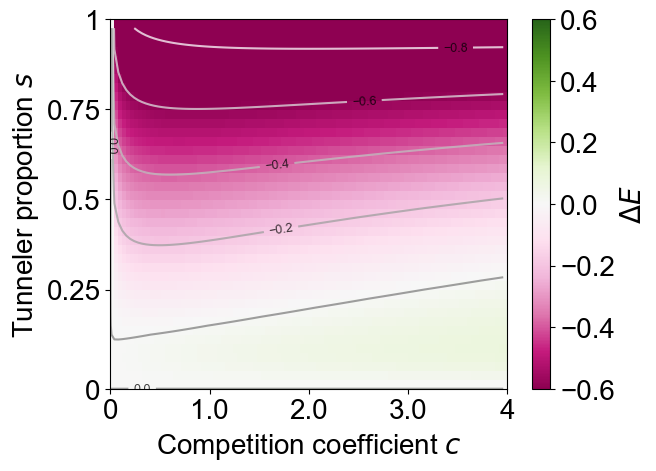

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 20

#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

I  = 100
z = 1



#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


z_l = [0.5, 2, 3]
for z in z_l:
    print("z=",z)

    # Seedling establishment probability
    def S(x):
        return 1 / (1+(c*(x**z)))



    # Parametr range of s and p.
    s_max = 1
    s_bunkatu = 41
    s_l = np.linspace(0, s_max, s_bunkatu)

    c_max = 4
    c_bunkatu = 100
    c = np.linspace(0, c_max, c_bunkatu)


    #Simulate Roller only community
    N1y_bf = I*n_r_bf

    NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
    NDr_single_bf = [T*D for D in D_rol]

    E_r_bf = [i* S(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
    E_sum_bf = (sum(E_r_bf))*dd



    E_Delta_l = []

    for s in s_l:

        n_r = (1-s)*K
        n_t = s*K

        n_r_af = n_r
        n_t_af = n_t



        ##Cal Seedling Roller + Tunneler 
        # print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

        Nr  = I*Fr*n_r
        Nt  = I*Ft*n_t


        Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
        Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

        NDr_total = [Nr*D for D in D_rol] 
        NDt_total = [Nt*D for D in D_tun]

        NDr_single = [Nr_single*D for D in D_rol] 
        NDt_single = [Nt_single*D for D in D_tun]


        ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
        ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 


        E_rt = [i* S(j) for i, j in zip(ND_total, ND_single)]


        E_sum_rt = (sum(E_rt))*dd
        E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf

        E_Delta_l.append(E_Delta)



    X = range(len(c)) 
    Y =range(len(s_l))

    plt.figure()
    plt.pcolor(E_Delta_l, 
            cmap='PiYG',
    vmin=-0.6,vmax=0.6,
    # aspect='auto', interpolation='none', origin='lower'
    )
    # plt.title("Seed Seedling Difference")
    plt.colorbar(label='$ΔE$')
    cs = plt.contour(X, Y, E_Delta_l,
                levels = [-0.8, -0.6, -0.4,-0.2, 0, 0.2, 0.4, 0.6, 0.8], 
                cmap="binary",
                alpha=0.75)
    plt.clabel(cs, fontsize=9, colors="black") 
    plt.xlabel(f"Competition coefficient $c$")
    plt.ylabel("Tunneler proportion $s$")


    plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
    plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75,  1]) #s

    plt.show()

Fig S3 ScenarioA Varying seeds number I

I_l=  25


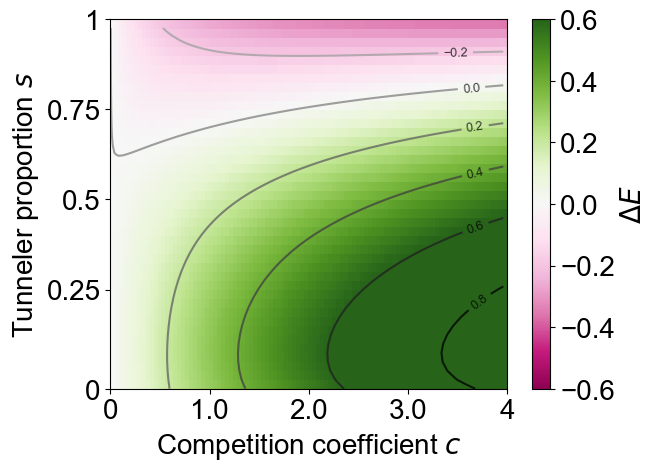

I_l=  50


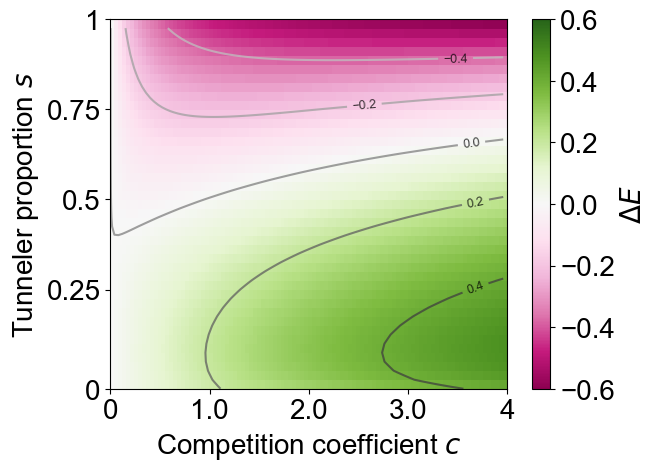

I_l=  100


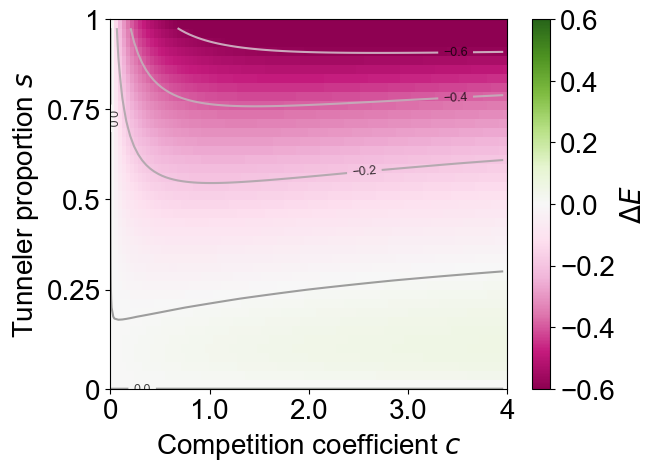

I_l=  150


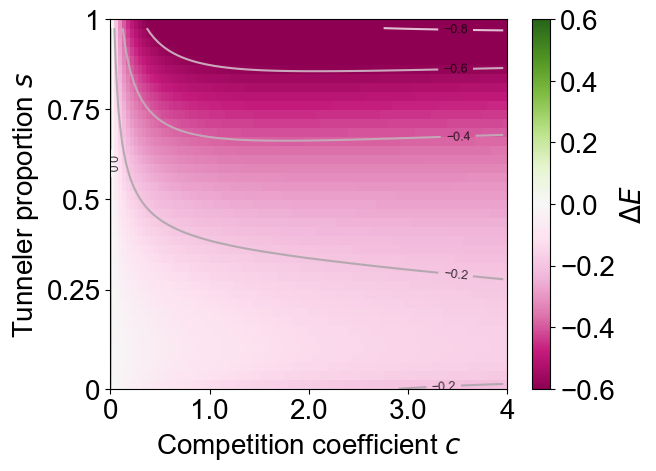

I_l=  200


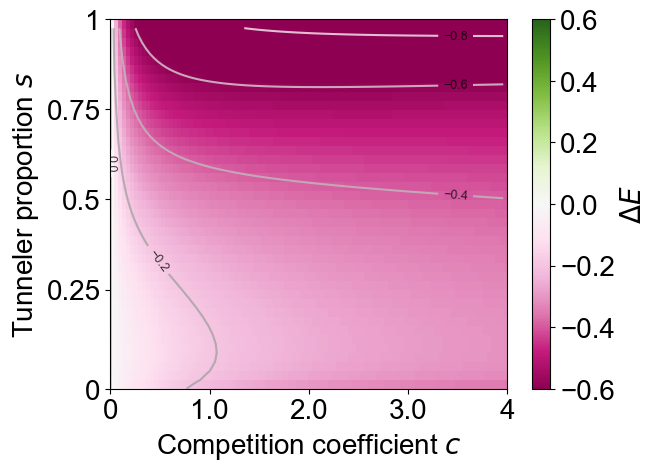

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 20

#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

I  = 100
# z = 2



# Dispersal by dung beetle
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 150
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


# Seedling establishment probability
def S(x):
    return 1 / (1+(c*(x**z)))



I_l= [25, 50, 100, 150, 200]

for I in I_l:
        
    print("I_l= ", I)

    # Parametr range of s and p.
    s_max = 1
    s_bunkatu = 41
    s_l = np.linspace(0, s_max, s_bunkatu)

    c_max = 4
    c_bunkatu = 100
    c = np.linspace(0, c_max, c_bunkatu)


    #Simulate Roller only community
    N1y_bf = I*n_r_bf

    NDr_total_bf = [I*Fr*n_r_bf*D for D in D_rol]
    NDr_single_bf = [T*D for D in D_rol]

    E_r_bf = [i* S(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
    E_sum_bf = (sum(E_r_bf))*dd



    E_Delta_l = []

    for s in s_l:

        n_r = (1-s)*K
        n_t = s*K

        n_r_af = n_r
        n_t_af = n_t


        ##Cal Seedling Roller + Tunneler 

        Nr  = I*Fr*n_r
        Nt  = I*Ft*n_t

        Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
        Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))

        NDr_total = [Nr*D for D in D_rol] 
        NDt_total = [Nt*D for D in D_tun]

        NDr_single = [Nr_single*D for D in D_rol] 
        NDt_single = [Nt_single*D for D in D_tun]


        ND_total = [Nr + Nt for Nr, Nt,  in zip (NDr_total, NDt_total) ] 
        ND_single = [x1 + y1 for x1, y1,  in zip (NDr_single, NDt_single) ] 


        E_rt = [i* S(j) for i, j in zip(ND_total, ND_single)]


        E_sum_rt = (sum(E_rt))*dd
        E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf

        E_Delta_l.append(E_Delta)



    X = range(len(c)) 
    Y =range(len(s_l))

    plt.figure()
    plt.pcolor(E_Delta_l, 
            cmap='PiYG',
    vmin=-0.6,vmax=0.6,
    # aspect='auto', interpolation='none', origin='lower'
    )
    # plt.title("Seed Seedling Difference")
    plt.colorbar(label='$ΔE$')
    cs = plt.contour(X, Y, E_Delta_l,
                levels = [-0.8, -0.6, -0.4,-0.2, 0, 0.2, 0.4, 0.6, 0.8], 
                cmap="binary",
                alpha=0.75)
    plt.clabel(cs, fontsize=9, colors="black") 
    plt.xlabel(f"Competition coefficient $c$")
    plt.ylabel("Tunneler proportion $s$")


    plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
    plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75,  1]) #s



    plt.show()

FIg S4　ScenarioB Varying seeds number I

I =  50


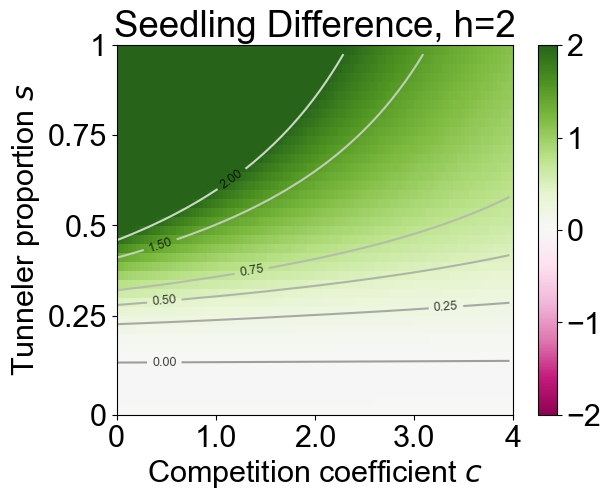

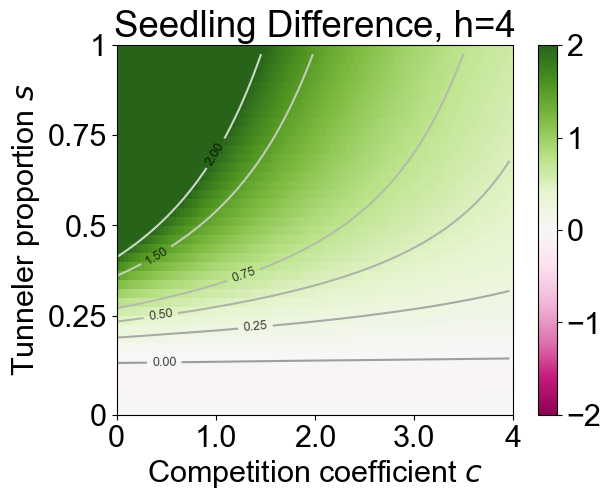

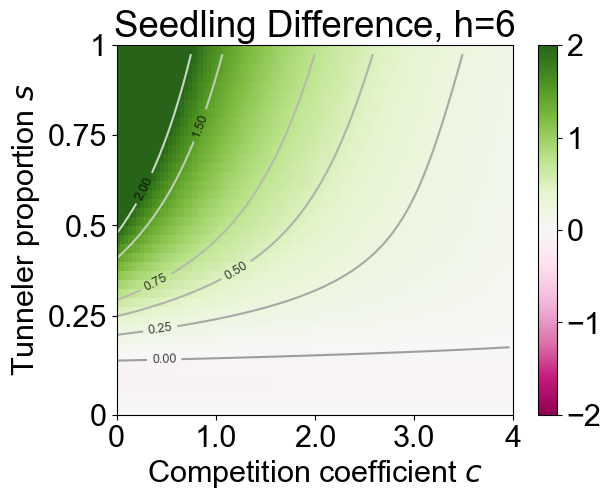

/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/216829995.py:222: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/216829995.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


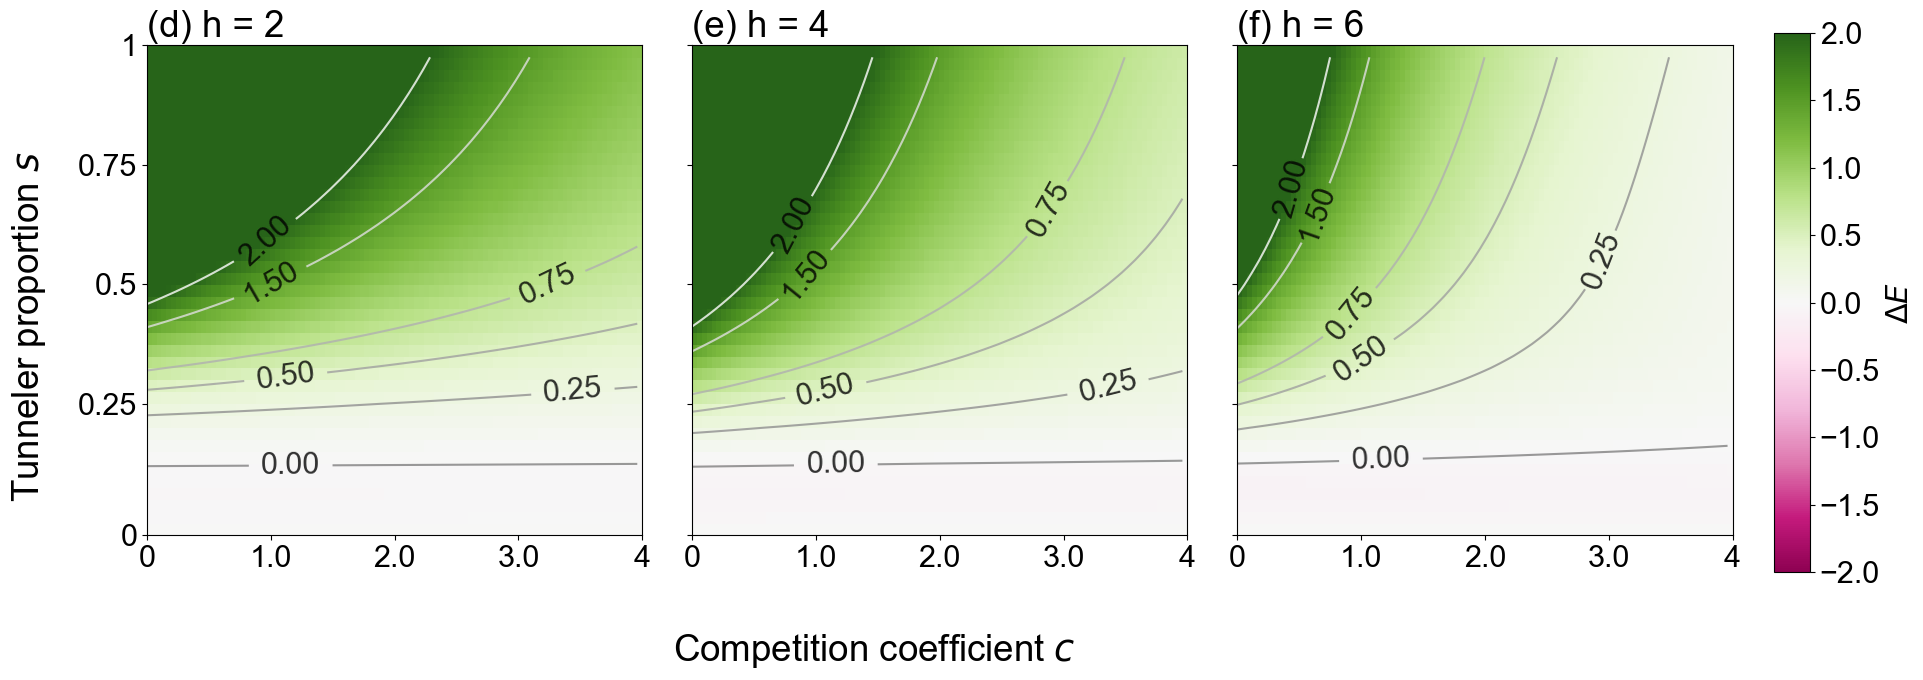

I =  150


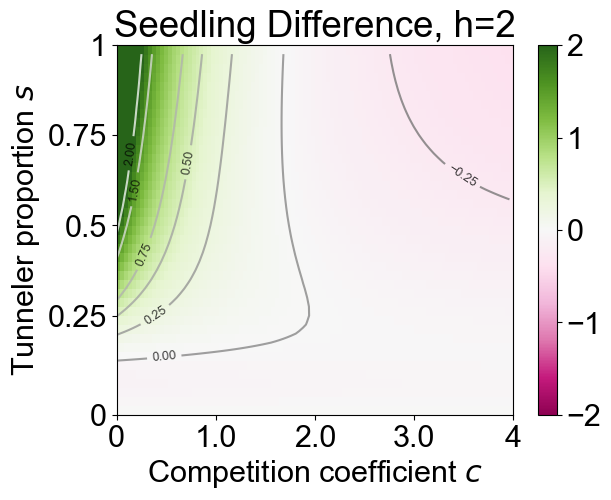

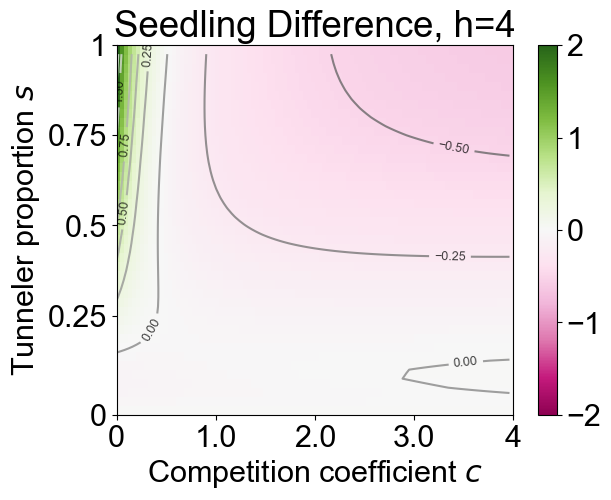

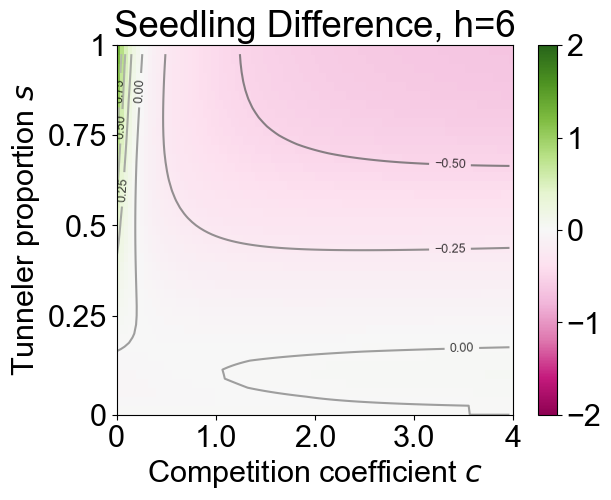

/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/216829995.py:222: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/216829995.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


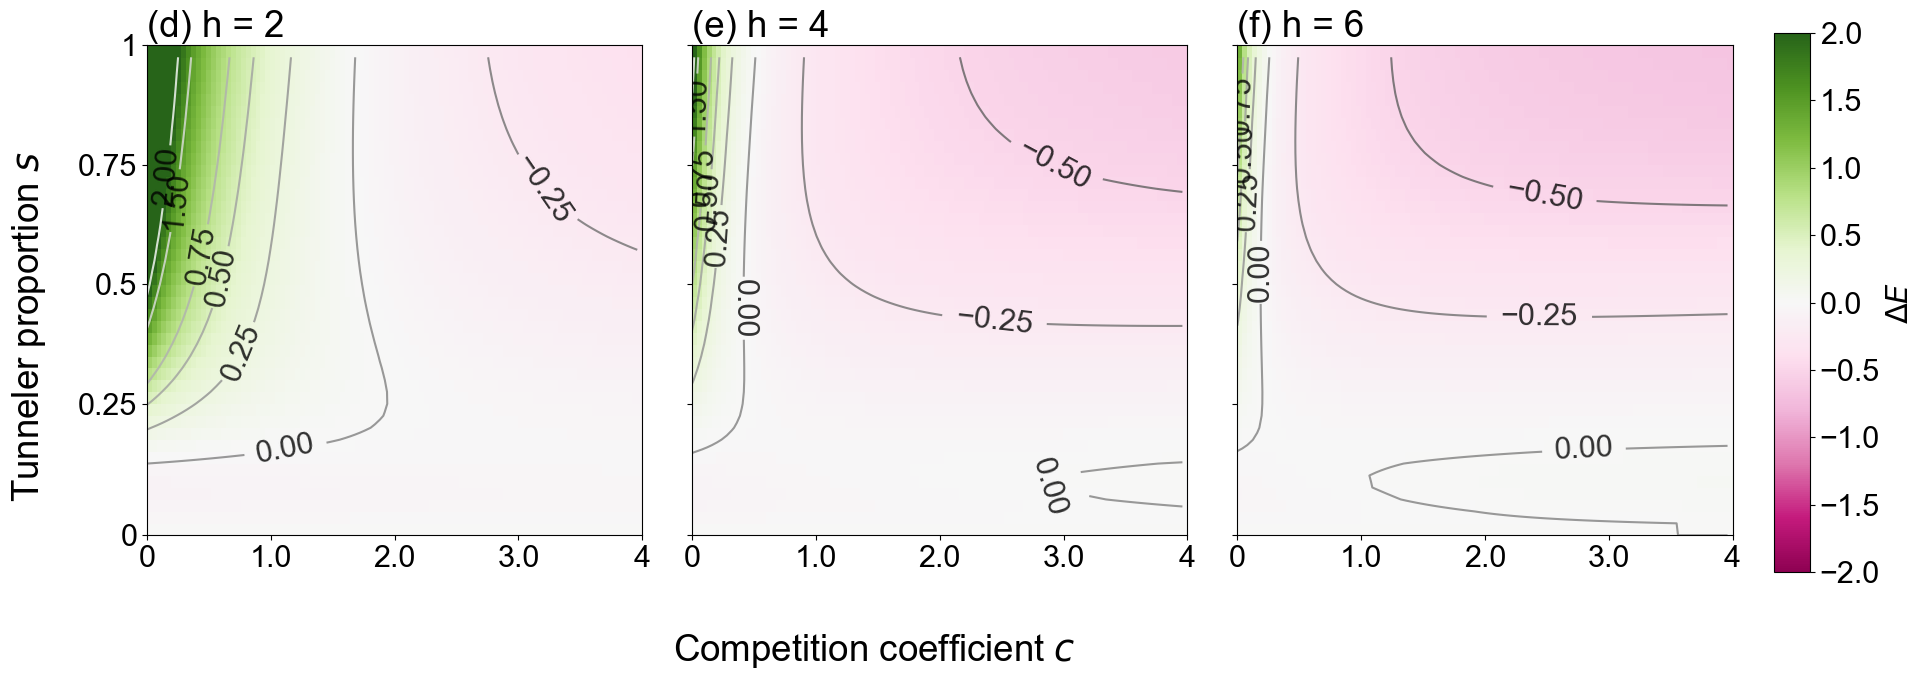

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.optimize import brentq


plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 22



#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

z= 1
I = 100

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

#Parameter setting
a = 1     #Attack rate
h = 10   #Handling time
n_p = 0.4      #Density of predetors


T_fixed =  10  #TIme to germination T



#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 100
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


# Parametr range of s and p.
s_max = 1
s_bunkatu = 41
s_l = np.linspace(0, s_max, s_bunkatu)

c_max = 4
c_bunkatu = 100
c = np.linspace(0, c_max, c_bunkatu)




def S(N):
    return 1 / (1+c*(N**(z)))


def P(n0_current):

    # Define the Equation
    def solve_nt(NT, a, h, n_p, N0, Time):
        if NT <= 0:
            return -np.inf
        
        term1 = np.log(NT) - np.log(N0)
        term2 = a * h * (NT - N0)
        term3 = a * n_p * Time
        return term1 + term2 + term3

    # Search range
    lower_bound = 1e-25
    upper_bound = n0_current
    
    if n0_current < 1e-5:
        return 0

    else: 
        try:
            nt_solution = brentq(
                solve_nt, lower_bound, upper_bound, 
                args=(a, h, n_p, n0_current, T_fixed) )
            
            # S(T) = N(T) / N(0)
            survival_rate = nt_solution / n0_current
            P_N = survival_rate
            return P_N    

        except ValueError:
            
            P_N = np.nan
        
            return P_N

def S_net(N):
    return P(N)*S(N*P(N))



I_l= [50, 150]

for I in I_l:
        
    print("I = ", I)

    E_Delta_ll = []

    h_l = [2, 4, 6]


    for h in h_l:
            
        E_Delta_l = []


        #Simulate Roller only community
        N1y_bf = I*n_r_bf

        NDr_total_bf = I*Fr*n_r_bf* D_rol
        NDr_single_bf = I * D_rol

        E_r_bf = [i* S_net(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
        E_sum_bf = (sum(E_r_bf))*dd


        for s in s_l:

            n_r = (1-s)*K
            n_t = s*K

            n_r_af = n_r
            n_t_af = n_t


            ##Cal Seedling Roller + Tunneler 
            # print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

            Nr  = I*Fr*n_r
            Nt  = I*Ft*n_t


            Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
            Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))


            NDr_total = Nr*D_rol
            NDt_total = Nt*D_tun

            NDr_single = Nr_single*D_rol 
            NDt_single = Nt_single* D_tun

            ND_total = NDr_total + NDt_total
            ND_single = NDr_single + NDt_single

            E_rt = [i* S_net(j) for i, j in zip(ND_total, ND_single)]


            E_sum_rt = (sum(E_rt))*dd
            E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf
            # E_Delta_l.append(E_Delta)
            E_Delta_l.append(E_Delta)

        E_Delta_ll.append(E_Delta_l)


        # Make figure
        X = range(len(c)) 
        Y =range(len(s_l))

        plt.figure()
        plt.pcolor(E_Delta_l, cmap='PiYG',
        vmin=-2,vmax=2,
        # aspect='auto', interpolation='none', origin='lower'
        )
        plt.title(f"Seedling Difference, h={h}")
        plt.colorbar()
        cs = plt.contour(X, Y, E_Delta_l,
                    levels = [-2.0, -1.5, -0.75, -0.5,-0.25, 0, 0.25, 0.5, 0.75, 1.5, 2.0], 
                    cmap="binary_r",
                    alpha=0.75)
        plt.clabel(cs, fontsize=9, colors="black") 
        plt.xlabel(f"Competition coefficient $c$")
        plt.ylabel("Tunneler proportion $s$")


        plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
        plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75, 1]) #s

        plt.show()



    # subplot
    fig, axes = plt.subplots(1, 3, tight_layout=True, figsize=(18, 7), sharex=True, sharey="row")
    ax1, ax2, ax3= axes[0], axes[1], axes[2] 
    ax_l= [ax1, ax2, ax3]
    title_l = [f"(d) h = {h_l[0]}", f"(e) h = {h_l[1]}", f"(f) h = {h_l[2]}"]


    for j in range(3):

        ax_l[j].set_title(title_l[j], loc="left")
        im = ax_l[j].pcolor(E_Delta_ll[j], cmap='PiYG',
                        vmin=-2,vmax=2,
                        # aspect='auto', interpolation='none', origin='lower'
                        )

        cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
                        levels = [-2.0, -1.5, -0.75, -0.5,-0.25, 0, 0.25, 0.5, 0.75, 1.5, 2.0], 
                        cmap="binary_r",
                        alpha=0.8,
                        linewidth=3)

        plt.clabel(cs, fontsize=22, colors="black")  

    plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
    plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75, 1]) #s


    cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.77])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('$\Delta E$') 

    fig.supxlabel(f"Competition coefficient $c$")
    fig.supylabel("Tunneler proportion $s$")

    fig.tight_layout()
    plt.show()


Fig S5　z=0.5, 1.5, 2. scenarioB

z=  0.5


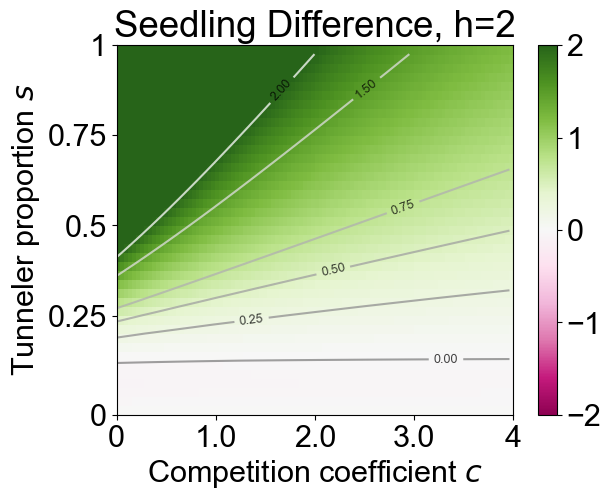

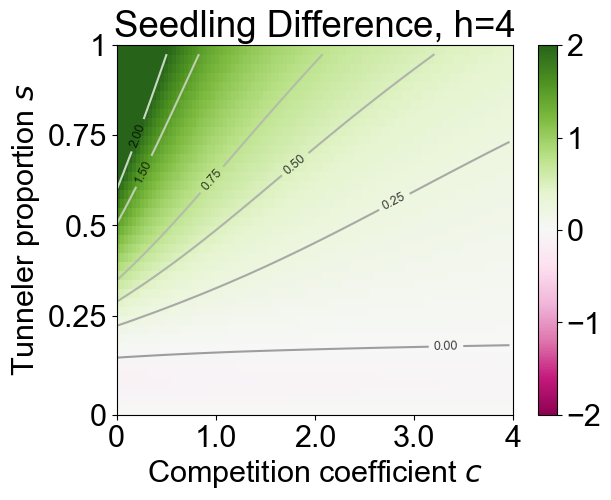

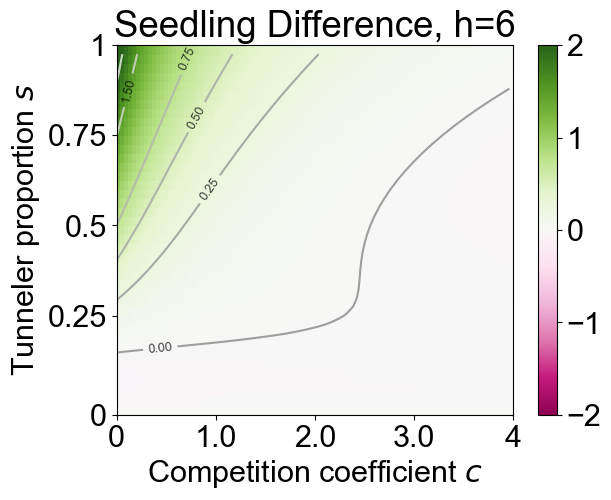

/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/3605655621.py:221: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/3605655621.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


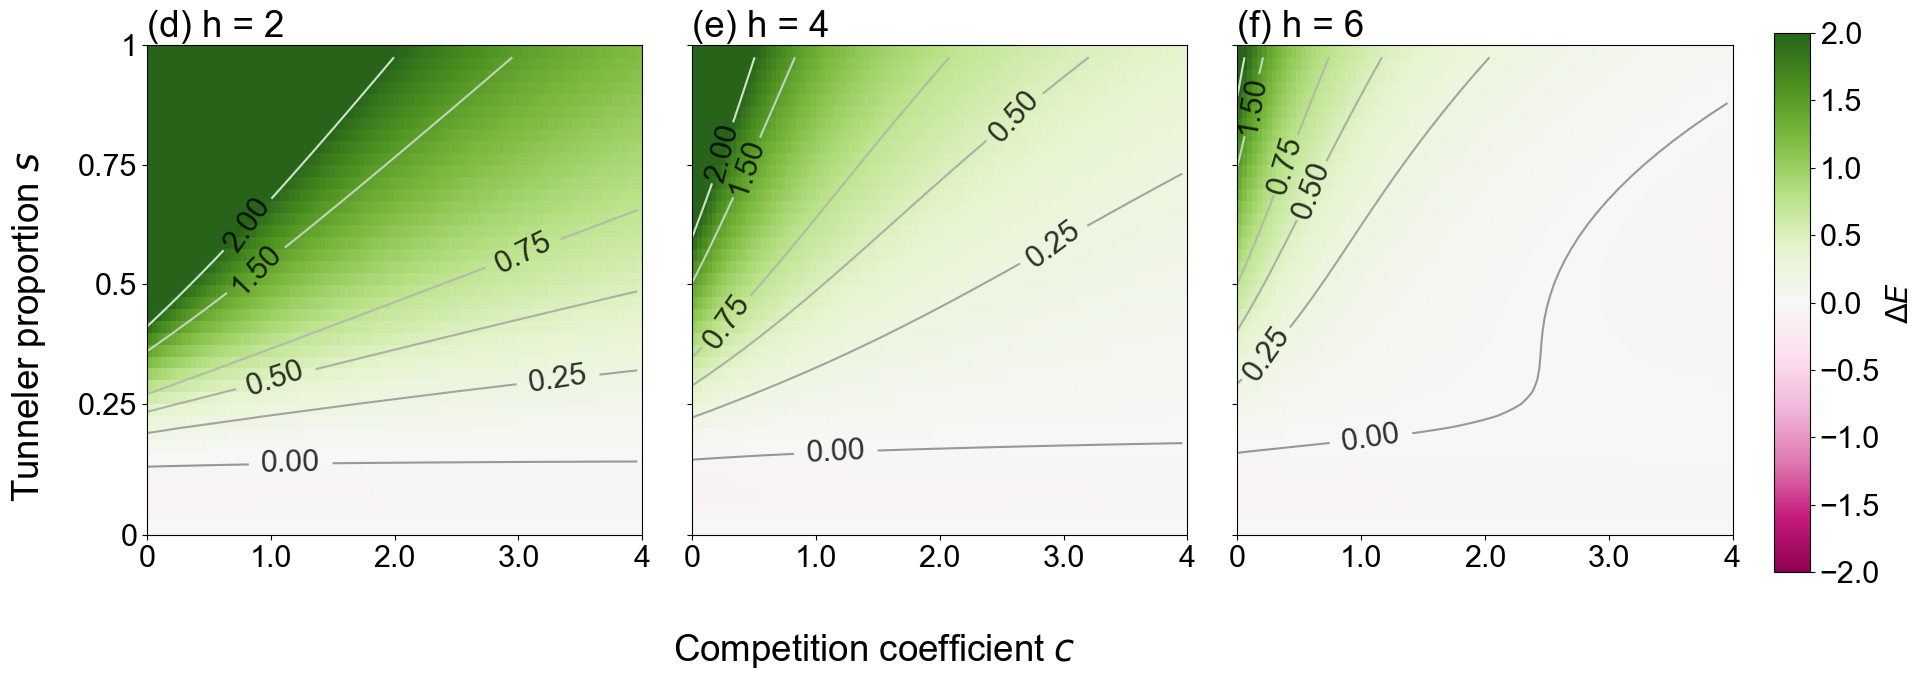

z=  1.5


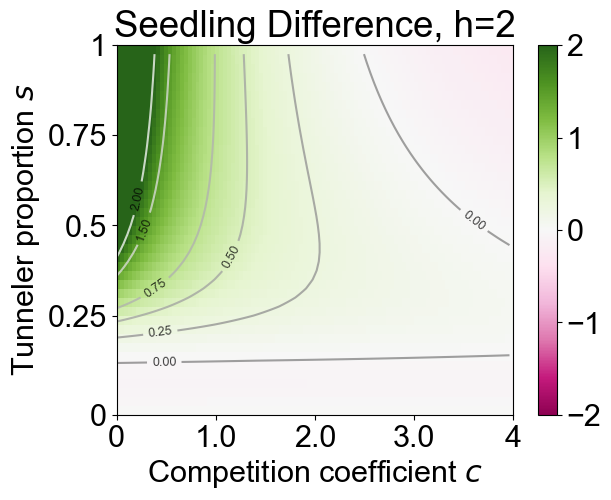

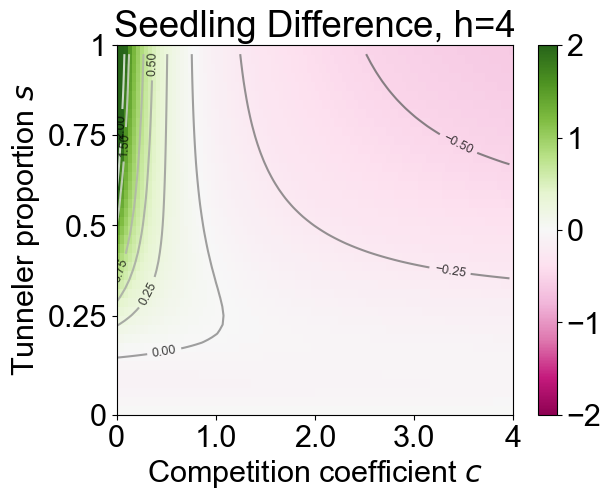

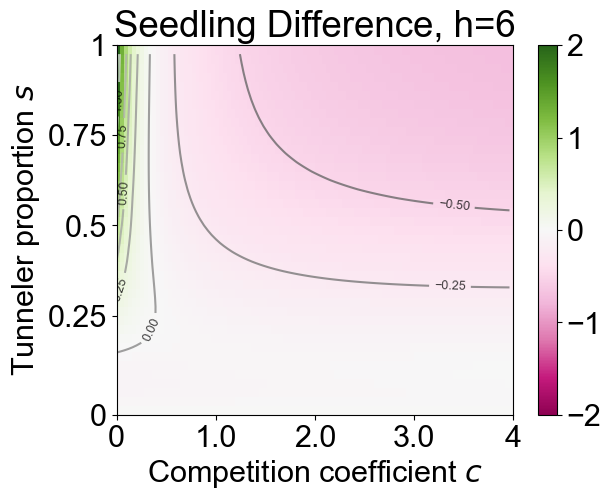

/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/3605655621.py:221: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
/var/folders/x5/dmqrr4f95xngl7ctpkngf6wh0000gn/T/ipykernel_41058/3605655621.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


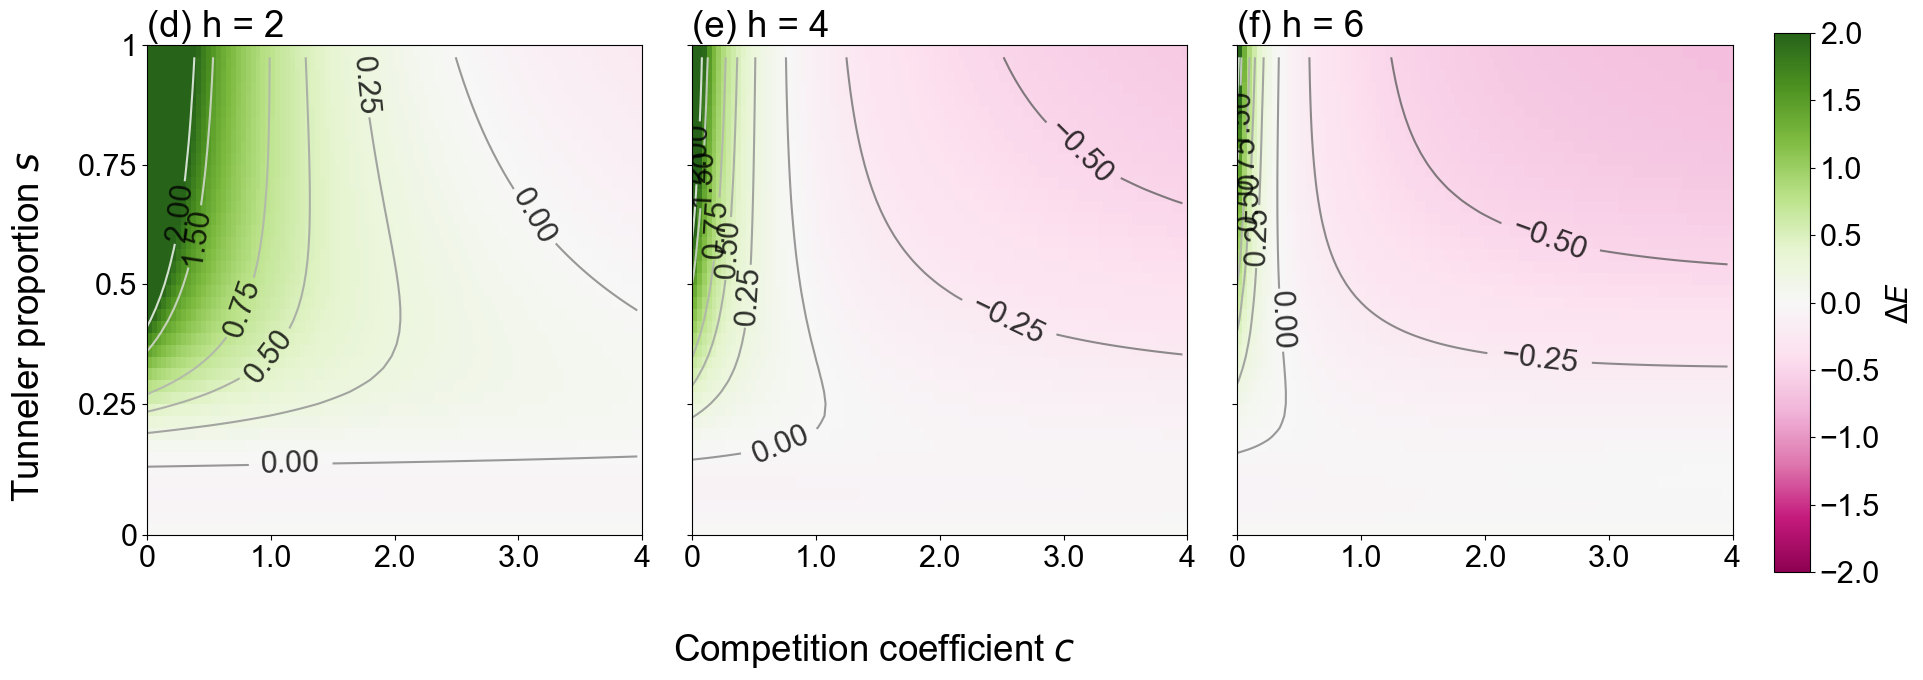

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.optimize import brentq


plt.rcParams['font.family'] = 'Arial' #Setting font
plt.rcParams["font.size"] = 22


#Parameter Set

K = 100 #Carrying capacity
n_r = K
n_r_bf = n_r

z= 1
I = 100

Fr = 1 #Feeding abundance
Ft = 1 #Feeding abundance

#Parameter setting
a = 1     #Attack rate
h = 10   #Handling time
n_p = 0.4      #Density of predetors


T_fixed =  10  #TIme to germination T



#Dispesals by tunneler dung beetle
# Parameters of Gamma distribution
shape_tun = 1  # Shaoe parameter (k)
scale_tun = 10  # Scale parameter (θ)

mean_rol = 100
varian_rol = 3600
shape_rol = (mean_rol**2) /varian_rol # Shaoe parameter (k)
scale_rol = varian_rol/mean_rol  # Scale parameter (θ)


# x axis generated
distance = 500
bunkatu = 10000
x_l = np.linspace(0, distance, bunkatu)  

dd = distance/bunkatu

#Probability Density Function
D_tun = gamma.pdf(x_l, a=shape_tun, scale=scale_tun)
D_rol = gamma.pdf(x_l, a=shape_rol, scale=scale_rol)


# Parametr range of s and p.
s_max = 1
s_bunkatu = 41
s_l = np.linspace(0, s_max, s_bunkatu)

c_max = 4
c_bunkatu = 100
c = np.linspace(0, c_max, c_bunkatu)




def S(N):
    return 1 / (1+c*(N**(z)))


def P(n0_current):

    # Define the Equation
    def solve_nt(NT, a, h, n_p, N0, Time):
        if NT <= 0:
            return -np.inf
        
        term1 = np.log(NT) - np.log(N0)
        term2 = a * h * (NT - N0)
        term3 = a * n_p * Time
        return term1 + term2 + term3

    # Search range
    lower_bound = 1e-25
    upper_bound = n0_current
    
    if n0_current < 1e-5:
        return 0

    else: 
        try:
            nt_solution = brentq(
                solve_nt, lower_bound, upper_bound, 
                args=(a, h, n_p, n0_current, T_fixed) )
            
            # S(T) = N(T) / N(0)
            survival_rate = nt_solution / n0_current
            P_N = survival_rate
            return P_N    

        except ValueError:
            P_N = np.nan
        
            return P_N

def S_net(N):
    return P(N)*S(N*P(N))



z_l= [0.5, 1.5]

for z in z_l:
        
    print("z= ", z)

    E_Delta_ll = []

    h_l = [2, 4, 6]


    for h in h_l:
            
        E_Delta_l = []


        N1y_bf = I*n_r_bf

        NDr_total_bf = I*Fr*n_r_bf* D_rol
        NDr_single_bf = I * D_rol

        E_r_bf = [i* S_net(j) for i, j in zip(NDr_total_bf, NDr_single_bf)]
        E_sum_bf = (sum(E_r_bf))*dd


        for s in s_l:

            n_r = (1-s)*K
            n_t = s*K

            n_r_af = n_r
            n_t_af = n_t


            ##Cal Seedling Roller + Tunneler 
            # print(f"After Fr*n_r={Fr*n_r}, G2n2={Ft*n_t}")

            Nr  = I*Fr*n_r
            Nt  = I*Ft*n_t


            Nr_single  = I*((Fr*n_r)/(Fr*n_r+Ft*n_t))
            Nt_single  = I*((Ft*n_t)/(Fr*n_r+Ft*n_t))


            NDr_total = Nr*D_rol
            NDt_total = Nt*D_tun

            NDr_single = Nr_single*D_rol 
            NDt_single = Nt_single* D_tun

            ND_total = NDr_total + NDt_total
            ND_single = NDr_single + NDt_single

            E_rt = [i* S_net(j) for i, j in zip(ND_total, ND_single)]


            E_sum_rt = (sum(E_rt))*dd
            E_Delta = (E_sum_rt- E_sum_bf)/E_sum_bf
            # E_Delta_l.append(E_Delta)
            E_Delta_l.append(E_Delta)

        E_Delta_ll.append(E_Delta_l)


        # Make figure
        X = range(len(c)) 
        Y =range(len(s_l))

        plt.figure()
        plt.pcolor(E_Delta_l, cmap='PiYG',
        vmin=-2,vmax=2,
        # aspect='auto', interpolation='none', origin='lower'
        )
        plt.title(f"Seedling Difference, h={h}")
        plt.colorbar()
        cs = plt.contour(X, Y, E_Delta_l,
                    levels = [-2.0, -1.5, -0.75, -0.5,-0.25, 0, 0.25, 0.5, 0.75, 1.5, 2.0], 
                    cmap="binary_r",
                    alpha=0.75)
        plt.clabel(cs, fontsize=9, colors="black") 
        plt.xlabel(f"Competition coefficient $c$")
        plt.ylabel("Tunneler proportion $s$")


        plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
        plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75, 1]) #s

        plt.show()



    # subplot
    fig, axes = plt.subplots(1, 3, tight_layout=True, figsize=(18, 7), sharex=True, sharey="row")
    ax1, ax2, ax3= axes[0], axes[1], axes[2] 
    ax_l= [ax1, ax2, ax3]
    title_l = [f"(d) h = {h_l[0]}", f"(e) h = {h_l[1]}", f"(f) h = {h_l[2]}"]


    for j in range(3):

        ax_l[j].set_title(title_l[j], loc="left")
        im = ax_l[j].pcolor(E_Delta_ll[j], cmap='PiYG',
                        vmin=-2,vmax=2,
                        # aspect='auto', interpolation='none', origin='lower'
                        )

        cs = ax_l[j].contour(X, Y, E_Delta_ll[j],
                        levels = [-2.0, -1.5, -0.75, -0.5,-0.25, 0, 0.25, 0.5, 0.75, 1.5, 2.0], 
                        cmap="binary_r",
                        alpha=0.8,
                        linewidth=3)

        plt.clabel(cs, fontsize=22, colors="black")  

    plt.xticks([0, c_bunkatu/4, 2*c_bunkatu/4, 3*c_bunkatu/4, c_bunkatu], [0, c_max/4, 2*c_max/4, 3*c_max/4, c_max]) #p
    plt.yticks([0, 11, 21, 31, 41], [0, 0.25, 0.5, 0.75, 1]) #s


    cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.77])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('$\Delta E$') 

    fig.supxlabel(f"Competition coefficient $c$")
    fig.supylabel("Tunneler proportion $s$")

    fig.tight_layout()
    plt.show()
